# Lets plot this situations

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base = Path.home() / "projects" / "metamers" / "brightness" / "data2"

def load(condition):
    """
    condition: 'blue', 'blue-yellow', 'blue-red', 'blue-fixed', 'blue-shifted'
    returns a pandas DataFrame
    """
    f = base / f"{condition}.txt"
    return pd.read_csv(f, sep="\t")

def findAggStim(df):
    """
    Find the stimulation period in the dataframe
    """
    # Filter only stimulation periods
    stim_df = df[df["Trig"] == 1]

    # Group by trial number and compute mean lux
    trial_means = stim_df.groupby("Stim").agg(
        mean_lux=("Lux", "mean"),
        blue=("Blue", "first"),     # BLUE is constant within a trial
        yellow=("Yellow", "first"), # optional
        red=("Red", "first"),       # optional
        blue2=("Blue2", "first")    # optional
    ).reset_index()
    return trial_means

def plot_blue_vs_lux(tri1, tri2, titlex, label1 = "condition1", label2 = "condition2"):
    plt.figure(figsize=(8,5))
    plt.plot(tri1["blue"], tri1["mean_lux"], "-o", color="blue", label=label1)
    plt.plot(tri2["blue"], tri2["mean_lux"], "-o", color="red", label=label2)
    plt.xlabel("Blue intensity (L2)")
    plt.ylabel("Mean Lux ")
    plt.title(titlex)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_2cond(condition1,condition2,titlex,label1,label2):
    df1 = load(condition1)
    df2 = load(condition2)
    df1 = findAggStim(df1)
    df2 = findAggStim(df2)
    plot_blue_vs_lux(df1,df2,titlex,label1,label2)
    
    

# Define the conditions

In [2]:
blueNF = "blue_NF"
blueF  = "blue_Filter"
byNF   = "blue-yellow_NF"
byF    = "blue-yellow_Filter"
brNF   = "blue-red_NF"
brF    = "blue-red_Filter"
bfNF   = "blue-fixed_NF"
bfF    = "blue-fixed_Filter"
bsNF   = "blue-shifted_NF"
bsF    = "blue-shifted_Filter"

# plots for Blue conditions 

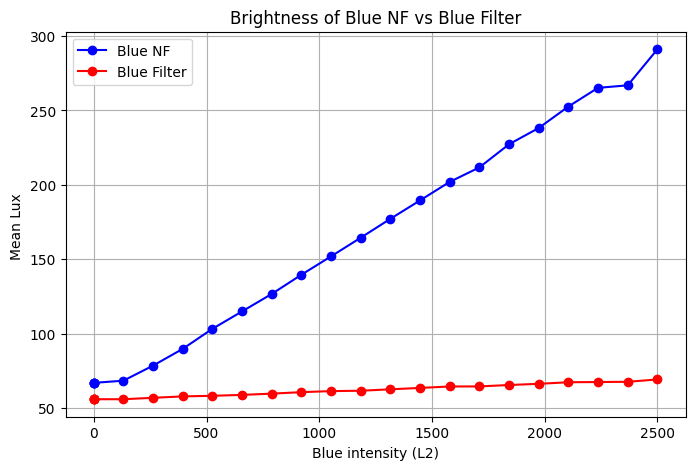

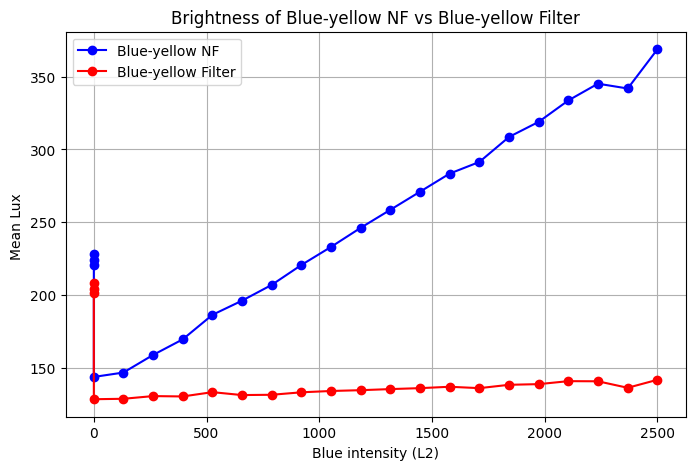

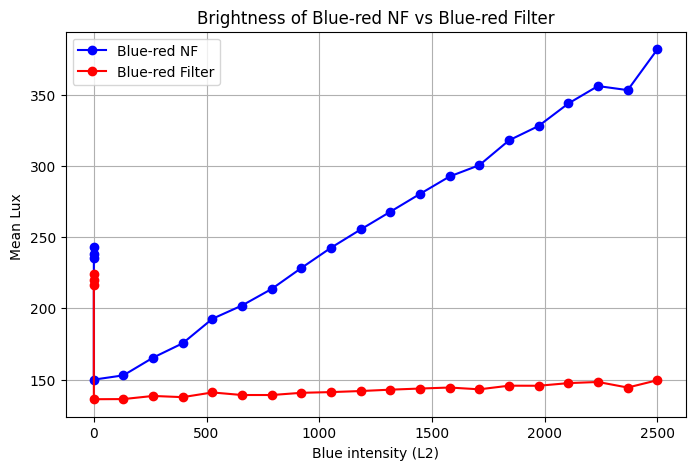

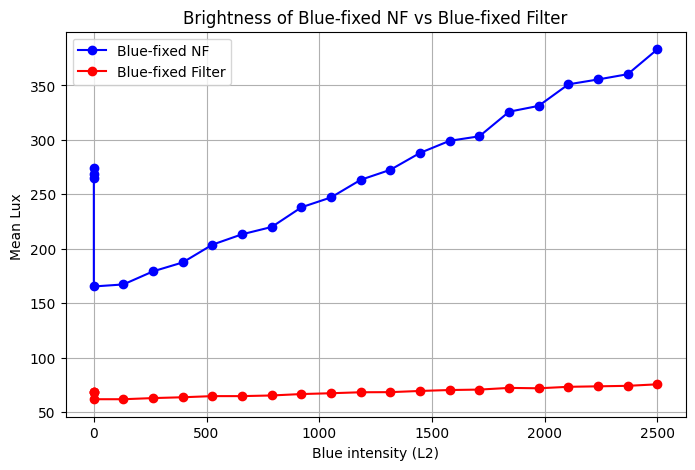

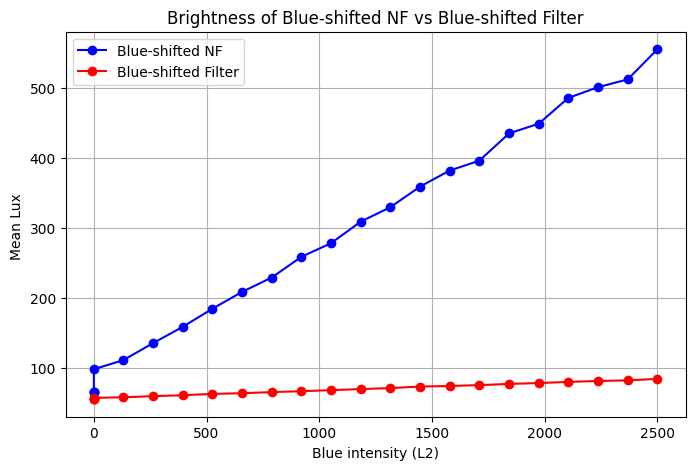

In [4]:
plot_2cond(blueNF,blueF,"Brightness of Blue NF vs Blue Filter","Blue NF","Blue Filter")
plot_2cond(byNF,byF,"Brightness of Blue-yellow NF vs Blue-yellow Filter","Blue-yellow NF","Blue-yellow Filter")
plot_2cond(brNF,brF,"Brightness of Blue-red NF vs Blue-red Filter","Blue-red NF","Blue-red Filter")
plot_2cond(bfNF,bfF,"Brightness of Blue-fixed NF vs Blue-fixed Filter","Blue-fixed NF","Blue-fixed Filter")
plot_2cond(bsNF,bsF,"Brightness of Blue-shifted NF vs Blue-shifted Filter","Blue-shifted NF","Blue-shifted Filter")


# Blue-Yellow plots

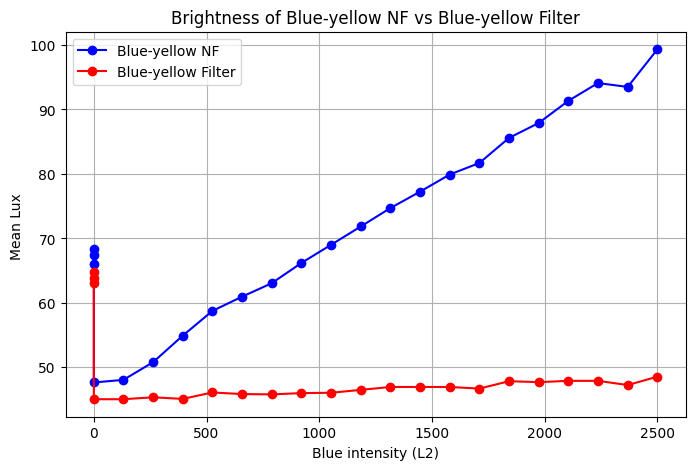

In [16]:
BYFi = load("blue-yellow_blueYFilter")
triBYFi = findAggStim(BYFi)

BYNF = load("blue-yellow_blueYellowNF")
triBYNF = findAggStim(BYNF)

plot_blue_vs_lux(triBYNF,triBYFi, "Brightness of Blue-yellow NF vs Blue-yellow Filter", "Blue-yellow NF", "Blue-yellow Filter")

# Blue-Red plots

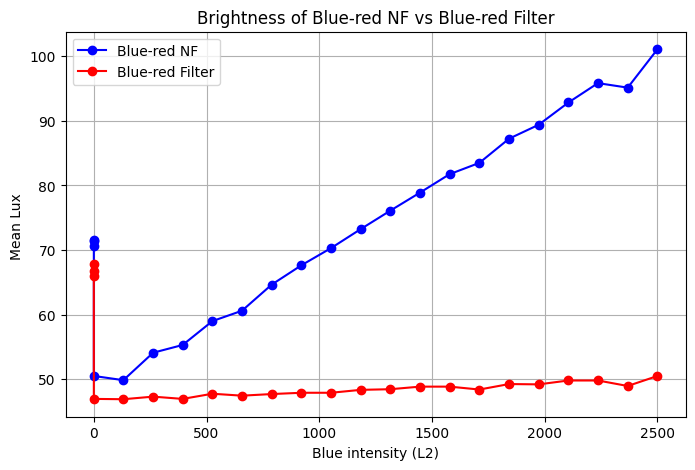

In [17]:
BRFi = load("blue-red_blueRFilter")
triBRFi = findAggStim(BRFi)

BRNF = load("blue-red_blueRedNF")
triBRNF = findAggStim(BRNF)

plot_blue_vs_lux(triBRNF,triBRFi, "Brightness of Blue-red NF vs Blue-red Filter", "Blue-red NF", "Blue-red Filter")

# Blue-Fixed plots

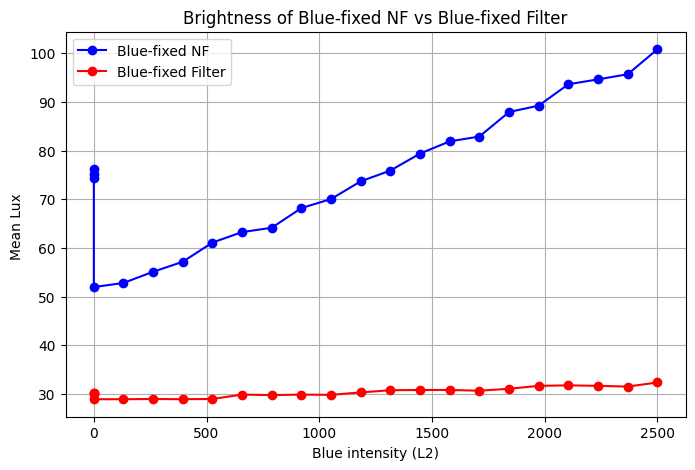

In [19]:
BFFi = load("blue-fixed_blueFixFilter")
triBFFi = findAggStim(BFFi)

BFNF = load("blue-fixed_blueFixedNF")
triBFNF = findAggStim(BFNF)

plot_blue_vs_lux(triBFNF,triBFFi, "Brightness of Blue-fixed NF vs Blue-fixed Filter", "Blue-fixed NF", "Blue-fixed Filter")

# Blue-Shifted plots

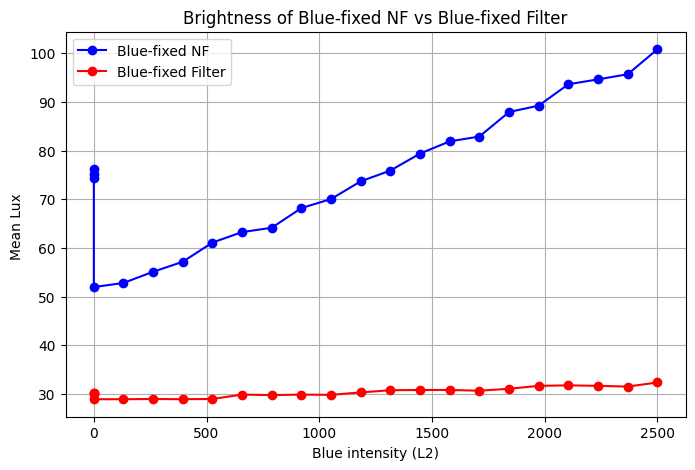

In [20]:
BSFi = load("blue-shifted_blueShiftedFilter")
triBSFi = findAggStim(BSFi)

BSNF = load("blue-shifted_blueshiftedNF")
triBSNF = findAggStim(BSNF)

plot_blue_vs_lux(triBFNF,triBFFi, "Brightness of Blue-fixed NF vs Blue-fixed Filter", "Blue-fixed NF", "Blue-fixed Filter")